<a href="https://colab.research.google.com/github/isamadafridi/-AIML-Internship-Week7-AbdulSamadAfridi/blob/main/pytorch_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install the latest versions of the required NLP libraries
!pip install transformers datasets accelerate evaluate -U

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 16.3 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: accelerate
    Found existing installation: accelerate 1.13.0
    Uninstalling accelerate-1.13.0:
      Successfully uninstalled accelerate-1.13.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.10.2
    Uninstalling trans

# Cell 2: Mount Drive & Load Data

In [2]:
import pandas as pd
from google.colab import drive

# 1. Mount Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# 2. Load your perfectly balanced, cleaned dataset
csv_path = "/content/drive/MyDrive/FYP/Pre_processing_data/master_dataset_protocol.csv"
df = pd.read_csv(csv_path)

print(f"✅ Successfully loaded dataset with {len(df)} URLs!")
print(df.info())

✅ Successfully loaded dataset with 617995 URLs!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 617995 entries, 0 to 617994
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   url     617995 non-null  object
 1   type    617995 non-null  object
dtypes: object(2)
memory usage: 9.4+ MB
None


# Cell 3: Stratified Splitting & Mapping

In [4]:
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer

print("1. Performing Stratified 80/10/10 Split...")
# Split 1: 80% Train, 20% Temp
train_df, temp_df = train_test_split(df, test_size=0.20, random_state=42, stratify=df['type'])
# Split 2: 10% Validation, 10% Test
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['type'])

# Map string labels to integers (0 = Benign, 1 = Phishing)
for dataframe in [train_df, val_df, test_df]:
    dataframe['labels'] = dataframe['type'].apply(lambda x: 1 if x == 'phishing' else 0)



1. Performing Stratified 80/10/10 Split...


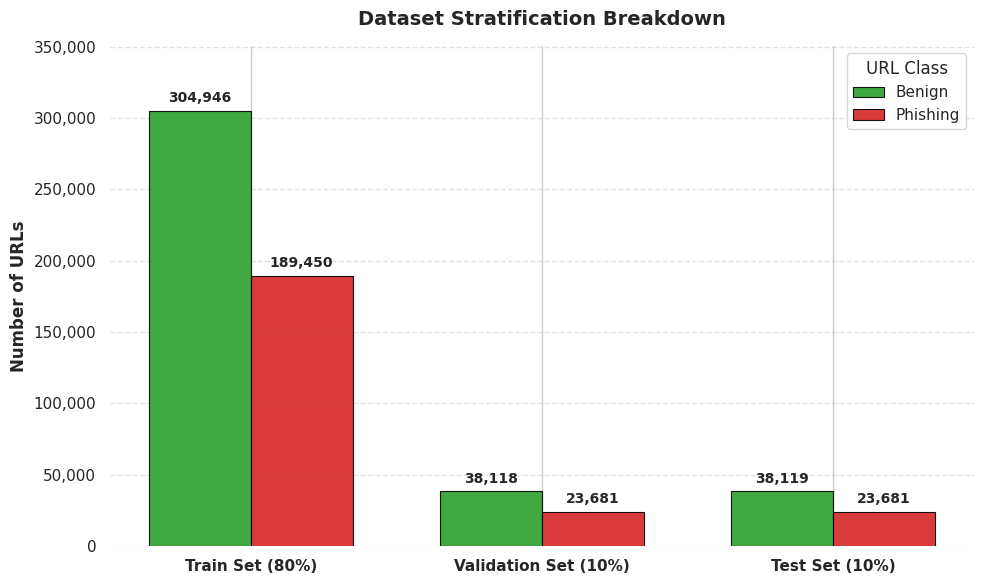

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 1. DYNAMICALLY extract the exact counts from your active DataFrames!
# (0 = Benign, 1 = Phishing)
benign_counts = [
    len(train_df[train_df['labels'] == 0]),
    len(val_df[val_df['labels'] == 0]),
    len(test_df[test_df['labels'] == 0])
]

phishing_counts = [
    len(train_df[train_df['labels'] == 1]),
    len(val_df[val_df['labels'] == 1]),
    len(test_df[test_df['labels'] == 1])
]

splits = ['Train Set (80%)', 'Validation Set (10%)', 'Test Set (10%)']

# 2. Set up the visual style
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(splits))  # Label locations
width = 0.35  # Width of the bars

# 3. Draw the bars
rects1 = ax.bar(x - width/2, benign_counts, width, label='Benign', color='#2ca02c', alpha=0.9, edgecolor='black', linewidth=0.8)
rects2 = ax.bar(x + width/2, phishing_counts, width, label='Phishing', color='#d62728', alpha=0.9, edgecolor='black', linewidth=0.8)

# 4. Add formal academic labels and formatting
ax.set_title('Dataset Stratification Breakdown', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Number of URLs', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(splits, fontsize=11, fontweight='bold')
ax.legend(title='URL Class', loc='upper right', frameon=True)

# Format the Y-axis to use commas for large numbers
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda val, loc: "{:,}".format(int(val))))

# 5. Automatically label the exact number at the top of each bar
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:,}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 4),  # 4 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

# Give the chart some breathing room at the top
ax.set_ylim(0, max(benign_counts) * 1.15)

# Clean up the layout
plt.grid(axis='y', linestyle='--', alpha=0.6)
sns.despine(left=True, bottom=True)
plt.tight_layout()

# 6. Save the dynamic, high-resolution visualization
plt.savefig('dynamic_stratification_graph.png', dpi=300, bbox_inches='tight')
plt.show()

#Cell 4: Mapping & Tokenization

In [6]:
print("2. Converting to Hugging Face Dataset...")
hg_dataset = DatasetDict({
    'train': Dataset.from_pandas(train_df[['url', 'labels']], preserve_index=False),
    'validation': Dataset.from_pandas(val_df[['url', 'labels']], preserve_index=False),
    'test': Dataset.from_pandas(test_df[['url', 'labels']], preserve_index=False)
})

print("3. Tokenizing URLs for DistilBERT...")
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize_func(batch):
    return tokenizer(batch["url"], padding="max_length", truncation=True, max_length=128)

tokenized_datasets = hg_dataset.map(tokenize_func, batched=True)

# Format the output strictly for PyTorch tensors
tokenized_datasets.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
print("✅ Data serialization complete and ready for PyTorch!")

2. Converting to Hugging Face Dataset...
3. Tokenizing URLs for DistilBERT...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/494396 [00:00<?, ? examples/s]

Map:   0%|          | 0/61799 [00:00<?, ? examples/s]

Map:   0%|          | 0/61800 [00:00<?, ? examples/s]

✅ Data serialization complete and ready for PyTorch!


# Cell 5: The PyTorch Training Loop

In [7]:
import os
import numpy as np
import torch
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

print("1. Initializing DistilBERT...")
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

print("\n2. Setting up Crash-Proof Checkpoints and Hyperparameters...")
drive_save_dir = "/content/drive/MyDrive/FYP/best_model/DistilBERT_PyTorch"
os.makedirs(drive_save_dir, exist_ok=True)

# The TrainingArguments handles everything Keras callbacks used to do
training_args = TrainingArguments(
    output_dir=drive_save_dir,
    eval_strategy="epoch",            # Evaluate accuracy at the end of every epoch
    save_strategy="epoch",            # Save a checkpoint to Drive at the end of every epoch
    num_train_epochs=4,               # 4 epochs is optimal for BERT models
    per_device_train_batch_size=16,   # Safe batch size for Colab T4 GPU
    per_device_eval_batch_size=16,
    learning_rate=5e-5,
    load_best_model_at_end=True,      # Automatically reload the best weights if overfitting occurs
    metric_for_best_model="accuracy",
    logging_dir=os.path.join(drive_save_dir, 'logs'),
)

# Define how PyTorch calculates our evaluation metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = (predictions == labels).mean()
    return {"accuracy": accuracy}

print("\n3. Initializing Trainer...")
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    compute_metrics=compute_metrics,
)

print("\n4. 🚀 BEGINNING TRAINING LOOP...")
# resume_from_checkpoint=False starts a fresh run.
trainer.train(resume_from_checkpoint=True) # if want to start from Zero keep it flase

print("\n5. Training Complete! Saving Final Production Model...")
final_model_path = os.path.join(drive_save_dir, "Final_Production_Model")
trainer.save_model(final_model_path)
tokenizer.save_pretrained(final_model_path)

print(f"✅ Master Model perfectly fine-tuned and securely saved to: {final_model_path}")

1. Initializing DistilBERT...


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.



2. Setting up Crash-Proof Checkpoints and Hyperparameters...

3. Initializing Trainer...

4. 🚀 BEGINNING TRAINING LOOP...


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


5. Training Complete! Saving Final Production Model...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Master Model perfectly fine-tuned and securely saved to: /content/drive/MyDrive/FYP/best_model/DistilBERT_PyTorch/Final_Production_Model


# Step 6

1. Running predictions on the unseen Test Set...



✅ Predictions Complete! Generating Thesis Metrics...

--------------------------------------------------
FINAL MODEL CLASSIFICATION REPORT
--------------------------------------------------
              precision    recall  f1-score   support

  Benign (0)     0.9964    0.9985    0.9975     38119
Phishing (1)     0.9976    0.9943    0.9959     23681

    accuracy                         0.9969     61800
   macro avg     0.9970    0.9964    0.9967     61800
weighted avg     0.9969    0.9969    0.9969     61800


📊 High-Resolution Confusion Matrix securely saved to: /content/drive/MyDrive/FYP/best_model/DistilBERT_PyTorch/confusion_matrix.png


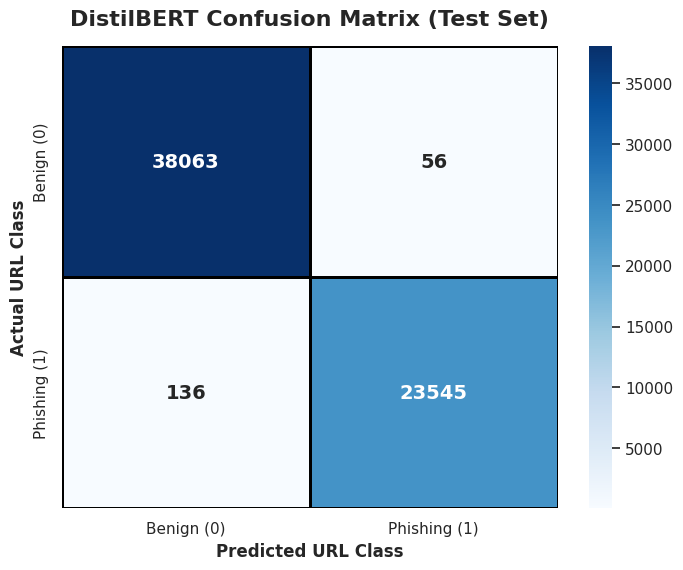

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("1. Running predictions on the unseen Test Set...")
# The trainer object from your last cell is still in memory, so we can use it directly!
predictions = trainer.predict(tokenized_datasets["test"])

# Extract the raw mathematical outputs (logits) and find the highest probability class
predicted_labels = np.argmax(predictions.predictions, axis=-1)
true_labels = predictions.label_ids

print("\n✅ Predictions Complete! Generating Thesis Metrics...\n")

# ==========================================
# 2. PRINT CLASSIFICATION REPORT
# ==========================================
target_names = ['Benign (0)', 'Phishing (1)']
print("-" * 50)
print("FINAL MODEL CLASSIFICATION REPORT")
print("-" * 50)
report = classification_report(true_labels, predicted_labels, target_names=target_names, digits=4)
print(report)

# ==========================================
# 3. GENERATE & SAVE CONFUSION MATRIX
# ==========================================
cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(8, 6))
sns.set_theme(style="white") # Clean background for academic papers

# Create a beautiful heatmap
heatmap = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                      xticklabels=target_names, yticklabels=target_names,
                      annot_kws={"size": 14, "weight": "bold"},
                      linewidths=1, linecolor='black')

plt.title('DistilBERT Confusion Matrix (Test Set)', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Actual URL Class', fontsize=12, fontweight='bold')
plt.xlabel('Predicted URL Class', fontsize=12, fontweight='bold')

# Save the high-resolution image for your FYP documentation
cm_save_path = '/content/drive/MyDrive/FYP/best_model/DistilBERT_PyTorch/confusion_matrix.png'
plt.savefig(cm_save_path, dpi=300, bbox_inches='tight')
print(f"\n📊 High-Resolution Confusion Matrix securely saved to: {cm_save_path}")

plt.show()

# Step 7 Testing

In [23]:
import torch
import torch.nn.functional as F

def scan_url(custom_url):
    print(f"🔍 Scanning: {custom_url}")

    # 1. Tokenize the raw text just like we did during training
    inputs = tokenizer(custom_url, return_tensors="pt", padding="max_length", truncation=True, max_length=128)

    # 2. Move the data to the GPU (where the model lives)
    device = trainer.model.device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # 3. Perform the prediction
    trainer.model.eval() # Lock the model into evaluation mode
    with torch.no_grad():
        outputs = trainer.model(**inputs)
        logits = outputs.logits

    # 4. Calculate the confidence percentage
    probabilities = F.softmax(logits, dim=-1)
    confidence = torch.max(probabilities).item() * 100
    predicted_class = torch.argmax(probabilities, dim=-1).item()

    # 5. Output the verdict
    print("-" * 50)
    if predicted_class == 1:
        print(f"🚨 VERDICT: PHISHING DETECTED")
    else:
        print(f"✅ VERDICT: SAFE / BENIGN")

    print(f"🧠 AI Confidence: {confidence:.2f}%")
    print("-" * 50)

# ==========================================
# TEST YOUR OWN LINKS HERE
# ==========================================

# Example 1: A sneaky phishing link
# scan_url("http://secure-update-billing-paypal.com/login")

print("\n")

# Example 2: Put your custom link inside the quotes below!
# my_link = "https://www.imsciences.edu.pk/student-portal"
my_link = "https://gemini.google.com"
scan_url(my_link)



🔍 Scanning: https://gemini.google.com
--------------------------------------------------
🚨 VERDICT: PHISHING DETECTED
🧠 AI Confidence: 99.89%
--------------------------------------------------


In [28]:
# !pip install tldextract

import tldextract
import torch
import torch.nn.functional as F

# 1. Define a robust Global Whitelist of highly trusted root domains
GLOBAL_WHITELIST = {
    "google.com", "microsoft.com", "apple.com", "amazon.com",
    "github.com", "edu.pk", "gov.pk", "imsciences.edu.pk"
}

def smart_phishing_scanner(url, model, tokenizer):
    print(f"🌐 Analyzing URL: {url}")

    # Step 1: Structural Parsing using TLDextract
    # This correctly extracts the registered root domain (e.g., 'google.com' from 'gemini.google.com')
    extracted = tldextract.extract(url)
    root_domain = f"{extracted.domain}.{extracted.suffix}"

    # Step 2: Whitelist Guardrail Check
    if root_domain in GLOBAL_WHITELIST:
        print("-" * 50)
        print("✅ VERDICT: SAFE (Verified Whitelist Domain)")
        print(f"ℹ️ Reason: Root domain '{root_domain}' bypassed NLP analysis.")
        print("-" * 50)
        return

    # Step 3: Fallback to Deep Learning if domain is unknown
    inputs = tokenizer(url, return_tensors="pt", padding="max_length", truncation=True, max_length=128)
    device = model.device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        probabilities = F.softmax(outputs.logits, dim=-1)

    confidence = torch.max(probabilities).item() * 100
    predicted_class = torch.argmax(probabilities, dim=-1).item()

    print("-" * 50)
    if predicted_class == 1:
        print(f"🚨 VERDICT: PHISHING DETECTED")
    else:
        print(f"✅ VERDICT: SAFE / BENIGN")
    print(f"🧠 Deep Learning Confidence: {confidence:.2f}%")
    print("-" * 50)


In [32]:
# ==========================================
# TEST THE HYBRID PIPELINE
# ==========================================
# This will now pass safely because 'google.com' is recognized structurally
smart_phishing_scanner("https://colab.research.google.com/drive/134OjVGKjihWrWAKvr0P9k6I12mcvBVM5?authuser=1#scrollTo=jcKKVJyQucLY", trainer.model, tokenizer)


🌐 Analyzing Input: 'https://colab.research.google.com/drive/134OjVGKjihWrWAKvr0P9k6I12mcvBVM5?authuser=1#scrollTo=jcKKVJyQucLY'
--------------------------------------------------
✅ VERDICT: SAFE (Verified Whitelist Domain)
ℹ️ Reason: Root domain 'google.com' bypassed deep learning analysis.
--------------------------------------------------


In [31]:
from urllib.parse import urlparse
import tldextract
import torch
import torch.nn.functional as F

# 1. Define the Global Whitelist
GLOBAL_WHITELIST = {
    "google.com", "microsoft.com", "apple.com", "amazon.com",
    "github.com", "edu.pk", "gov.pk", "imsciences.edu.pk"
}

# 2. Define the Gatekeeper Function
def is_valid_url(url):
    """Checks if the input is structurally a valid web address."""
    try:
        result = urlparse(url)
        # It must explicitly declare HTTP or HTTPS, and have a domain
        if result.scheme not in ['http', 'https', 'www'] or not result.netloc:
            return False

        # It must not contain raw spaces
        if " " in url:
            return False

        return True
    except Exception:
        return False

# 3. The Master Scanning Pipeline
def smart_phishing_scanner(url, model, tokenizer):
    print(f"\n🌐 Analyzing Input: '{url}'")

    # Step 0: The Gatekeeper (Fail Fast)
    if not is_valid_url(url):
        print("-" * 50)
        print("❌ VERDICT: INVALID INPUT")
        print("ℹ️ Reason: The text provided is not a structurally valid URL. Dropping request.")
        print("-" * 50)
        return

    # Step 1: Structural Parsing & Whitelist Check
    extracted = tldextract.extract(url)
    root_domain = f"{extracted.domain}.{extracted.suffix}"

    if root_domain in GLOBAL_WHITELIST:
        print("-" * 50)
        print("✅ VERDICT: SAFE (Verified Whitelist Domain)")
        print(f"ℹ️ Reason: Root domain '{root_domain}' bypassed deep learning analysis.")
        print("-" * 50)
        return

    # Step 2: Deep Learning Inference (Only runs if the URL is valid and unknown)
    print("⏳ Unknown domain detected. Routing to DistilBERT for deep analysis...")
    inputs = tokenizer(url, return_tensors="pt", padding="max_length", truncation=True, max_length=128)
    device = model.device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        probabilities = F.softmax(outputs.logits, dim=-1)

    confidence = torch.max(probabilities).item() * 100
    predicted_class = torch.argmax(probabilities, dim=-1).item()

    print("-" * 50)
    if predicted_class == 1:
        print(f"🚨 VERDICT: PHISHING DETECTED")
    else:
        print(f"✅ VERDICT: SAFE / BENIGN")
    print(f"🧠 AI Confidence: {confidence:.2f}%")
    print("-" * 50)

# ==========================================
# TEST THE BULLETPROOF PIPELINE
# ==========================================
smart_phishing_scanner("hello world", trainer.model, tokenizer)
smart_phishing_scanner("www.imsciences.edu.pk", trainer.model, tokenizer) # Missing https://
smart_phishing_scanner("https://secure-login-attempt.com", trainer.model, tokenizer)


🌐 Analyzing Input: 'hello world'
--------------------------------------------------
❌ VERDICT: INVALID INPUT
ℹ️ Reason: The text provided is not a structurally valid URL. Dropping request.
--------------------------------------------------

🌐 Analyzing Input: 'www.imsciences.edu.pk'
--------------------------------------------------
❌ VERDICT: INVALID INPUT
ℹ️ Reason: The text provided is not a structurally valid URL. Dropping request.
--------------------------------------------------

🌐 Analyzing Input: 'https://secure-login-attempt.com'
⏳ Unknown domain detected. Routing to DistilBERT for deep analysis...
--------------------------------------------------
🚨 VERDICT: PHISHING DETECTED
🧠 AI Confidence: 100.00%
--------------------------------------------------
